# FIT5217 Assignment 2 - Task 2

**Name:** Jili Chen  
**Student ID:** 35423757

**AI Usage Declaration:** Option 3 - I used generative AI tools for coding support, debugging, understanding model behavior, and drafting analysis. All outputs were reviewed, validated, and adapted by me.

## Table of Contents

1. T2.1 T5 Fine-tuning with LoRA
2. T2.2 GPT-2 Fine-tuning with LoRA
3. T2.3 Cross-model Analysis


In [1]:
import sys
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import display

NOTEBOOK_DIR = Path.cwd()
ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
sys.path.append(str(ROOT))
sys.path.append("..")

from src.utils import set_seed

set_seed(42)

is_colab = "google.colab" in sys.modules
print(f"Environment: {'Colab' if is_colab else 'Local'}")
print(f"Project root: {ROOT}")
print(f"Python executable: {sys.executable}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Environment: Local
Project root: /Users/nili/Desktop/fit5217_a2
Python executable: /opt/anaconda3/bin/python
PyTorch version: 2.8.0
CUDA available: False


## T2.1 T5 Fine-tuning with LoRA

T5 was fine-tuned as a text-to-text model: both the input ingredients and the output recipe were represented as strings. The input prompt followed the format `generate recipe from ingredients: ...`, which gives the model an explicit generation instruction while keeping the source compact. The target recipe was serialized as numbered steps, for example `1. Mix ingredients. 2. Bake until done.`, so the generated output remains close to the evaluation format. Parameter-efficient fine-tuning was implemented with LoRA through `peft`. Three configurations were compared: a smaller adapter on query/value projections, a higher-rank query/value adapter, and a wider target-module setup covering query, key, value, and output projections. This isolates whether extra adapter rank or broader attention-module coverage is more useful under a fixed training budget.

In [2]:
t5_lora_configs = pd.DataFrame([
    {"Config": "config1", "r": 8, "alpha": 16, "dropout": 0.05, "target_modules": "q, v", "trainable_params": 294_912, "total_params": 60_801_536, "trainable_ratio": "0.485%"},
    {"Config": "config2", "r": 16, "alpha": 32, "dropout": 0.05, "target_modules": "q, v", "trainable_params": 589_824, "total_params": 61_096_448, "trainable_ratio": "0.965%"},
    {"Config": "config3", "r": 8, "alpha": 16, "dropout": 0.10, "target_modules": "q, k, v, o", "trainable_params": 589_824, "total_params": 61_096_448, "trainable_ratio": "0.965%"},
])
display(t5_lora_configs)
print("T5 LoRA configuration table loaded from recorded experiment settings.")


,Config,r,alpha,dropout,target_modules,trainable_params,total_params,trainable_ratio
0,config1,8,16,0.05,"q, v",294912,60801536,0.485%
1,config2,16,32,0.05,"q, v",589824,61096448,0.965%
2,config3,8,16,0.10,"q, k, v, o",589824,61096448,0.965%


T5 LoRA configuration table loaded from recorded experiment settings.


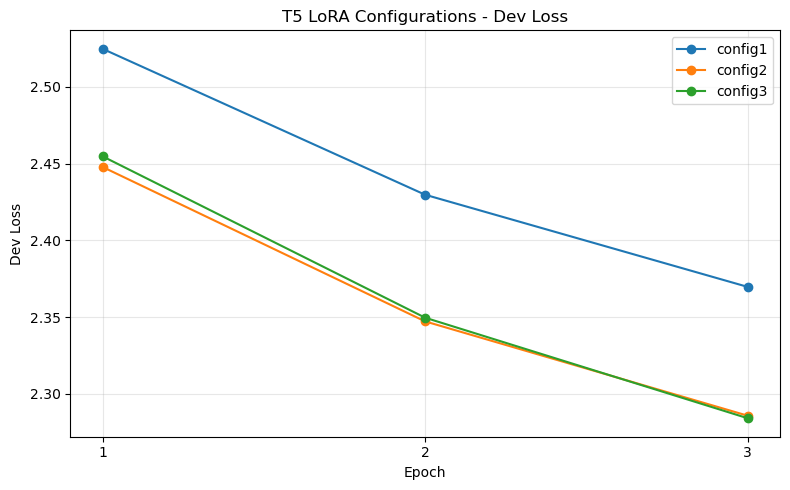

,config,epoch,train_loss,dev_loss
0,config1,1,2.936752,2.524869
1,config1,2,2.706262,2.429804
2,config1,3,2.628540,2.369758
3,config2,1,2.859496,2.447903
4,config2,2,2.617463,2.347289
5,config2,3,2.530356,2.285845
6,config3,1,2.878772,2.454834
7,config3,2,2.620383,2.349697
8,config3,3,2.526998,2.284195


In [3]:
def load_training_history(config_name):
    path = ROOT / "checkpoints" / config_name / "best" / "training_state.json"
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    return pd.DataFrame(data["history"]), data

plt.figure(figsize=(8, 5))
t5_histories = {}
for config_name in ["t2_t5_config1", "t2_t5_config2", "t2_t5_config3"]:
    hist_df, state = load_training_history(config_name)
    t5_histories[config_name] = hist_df
    plt.plot(hist_df["epoch"], hist_df["dev_loss"], marker="o", label=config_name.replace("t2_t5_", ""))

plt.title("T5 LoRA Configurations - Dev Loss")
plt.xlabel("Epoch")
plt.ylabel("Dev Loss")
plt.xticks([1, 2, 3])
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

summary = pd.concat(
    [df.assign(config=name.replace("t2_t5_", "")) for name, df in t5_histories.items()],
    ignore_index=True,
)[["config", "epoch", "train_loss", "dev_loss"]]
display(summary)


In [4]:
t5_metrics = pd.DataFrame([
    {"Config": "config1", "BLEU-4": 0.0556, "METEOR": 0.2094, "BERTScore": 0.8661},
    {"Config": "config2", "BLEU-4": 0.0664, "METEOR": 0.2172, "BERTScore": 0.8677},
    {"Config": "config3", "BLEU-4": 0.0608, "METEOR": 0.2135, "BERTScore": 0.8686},
])
display(t5_metrics)

with open(ROOT / "outputs" / "predictions" / "t2_t5_t2_t5_config2_test.json", "r", encoding="utf-8") as f:
    t5_config2_predictions = json.load(f)

test_df = pd.read_csv(ROOT / "data" / "raw" / "test.csv")
sample_rows = []
for idx in range(3):
    sample_rows.append({
        "Index": idx,
        "Ingredients": test_df.loc[idx, "Ingredients"],
        "Gold Recipe": test_df.loc[idx, "Recipe"],
        "Config2 Generated": t5_config2_predictions[idx]["prediction"],
    })

display(pd.DataFrame(sample_rows))
print(f"Loaded {len(t5_config2_predictions)} T5 config2 predictions.")


,Config,BLEU-4,METEOR,BERTScore
0,config1,0.0556,0.2094,0.8661
1,config2,0.0664,0.2172,0.8677
2,config3,0.0608,0.2135,0.8686


,Index,Ingredients,Gold Recipe,Config2 Generated
0,0,"[""1 (8 oz.) pkg. cream cheese"", ""1 small jar M...","[""Whip cream cheese with mixer until smooth."",...","1. Mix cream cheese, Marshmallow Creme and ora..."
1,1,"[""1 lb. ground beef"", ""1/2 c. onions, cut up (...","[""Combine all ingredients."", ""Cook 30 minutes....",1. Brown ground beef and onions in butter. 2. ...
2,2,"[""1 large box lemon jello"", ""1 large can crush...","[""Drain juice from pineapple and save."", ""Prep...","1. Mix jello, pineapple and Cool Whip. 2. Mix ..."


Loaded 1081 T5 config2 predictions.


Config2 achieved the strongest BLEU among the T5 LoRA runs, followed by config3 and then config1. This suggests that increasing `lora_r` from 8 to 16 on the query and value projections was more effective than expanding the same rank across `q`, `k`, `v`, and `o`. Config3 had the same number of trainable parameters as config2, but its capacity was distributed across more projection matrices and used higher dropout. Under only three epochs, the higher-rank focused adapter appears to learn the most useful generation behavior faster. The results support a practical capacity trade-off: LoRA quality is not determined only by the parameter count, but also by where the trainable rank is placed inside the attention layers.

## T2.2 GPT-2 Fine-tuning with LoRA

GPT-2 was fine-tuned as a decoder-only language model using one concatenated sequence. The prompt contains the ingredients and a clear delimiter, then the recipe continuation follows. During training, labels for the ingredient and prompt section are masked to `-100`, so loss is only computed on the recipe tokens. This matches the conditional generation objective while preserving GPT-2's next-token prediction format. We added a safeguard ensuring at least a minimum number of recipe target tokens are preserved when ingredients are truncated. Without this, all labels could collapse to `-100` and produce NaN loss. The LoRA setup used `r=8`, `alpha=16`, `dropout=0.05`, and `target_modules=[c_attn]`, resulting in only 0.236% trainable parameters.

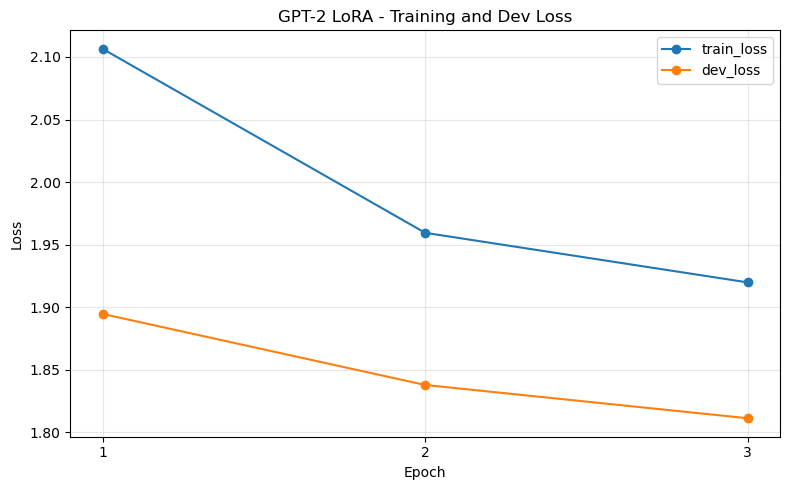

,epoch,global_step,train_loss,dev_loss
0,1,10182,2.106495,1.894702
1,2,20364,1.959504,1.837935
2,3,30546,1.919871,1.811352


Best checkpoint epoch: 3, global step: 30546


In [5]:
gpt2_hist_df, gpt2_state = load_training_history("t2_gpt2")

plt.figure(figsize=(8, 5))
plt.plot(gpt2_hist_df["epoch"], gpt2_hist_df["train_loss"], marker="o", label="train_loss")
plt.plot(gpt2_hist_df["epoch"], gpt2_hist_df["dev_loss"], marker="o", label="dev_loss")
plt.title("GPT-2 LoRA - Training and Dev Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks([1, 2, 3])
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

display(gpt2_hist_df[["epoch", "global_step", "train_loss", "dev_loss"]])
print(f"Best checkpoint epoch: {gpt2_state['epoch']}, global step: {gpt2_state['global_step']}")


In [6]:
gpt2_metrics = pd.DataFrame([
    {"Decoding Strategy": "greedy", "BLEU-4": 0.0438, "METEOR": 0.2496, "BERTScore": 0.8560},
    {"Decoding Strategy": "beam", "BLEU-4": 0.0534, "METEOR": 0.2574, "BERTScore": 0.8607},
])
display(gpt2_metrics)

with open(ROOT / "outputs" / "predictions" / "t2_gpt2_greedy_test.json", "r", encoding="utf-8") as f:
    gpt2_greedy = json.load(f)
with open(ROOT / "outputs" / "predictions" / "t2_gpt2_beam_test.json", "r", encoding="utf-8") as f:
    gpt2_beam = json.load(f)

comparison_rows = []
for idx in range(2):
    comparison_rows.append({
        "Index": idx,
        "Ingredients": test_df.loc[idx, "Ingredients"],
        "Gold Recipe": test_df.loc[idx, "Recipe"],
        "Greedy Generated": gpt2_greedy[idx]["prediction"],
        "Beam Generated": gpt2_beam[idx]["prediction"],
    })

display(pd.DataFrame(comparison_rows))
print(f"Loaded GPT-2 predictions: greedy={len(gpt2_greedy)}, beam={len(gpt2_beam)}")


,Decoding Strategy,BLEU-4,METEOR,BERTScore
0,greedy,0.0438,0.2496,0.8560
1,beam,0.0534,0.2574,0.8607


,Index,Ingredients,Gold Recipe,Greedy Generated,Beam Generated
0,0,"[""1 (8 oz.) pkg. cream cheese"", ""1 small jar M...","[""Whip cream cheese with mixer until smooth."",...",1. Blend cream cheese and Marshmallow Creme to...,1. Mix cream cheese and Marshmallow Creme toge...
1,1,"[""1 lb. ground beef"", ""1/2 c. onions, cut up (...","[""Combine all ingredients."", ""Cook 30 minutes....",1. Brown ground beef and onions in a skillet.\...,1. Brown ground beef.\n2. Add onions and musta...


Loaded GPT-2 predictions: greedy=1081, beam=1081


Beam decoding outperformed greedy decoding across all three metrics. The BLEU-4 score improved from 0.0438 to 0.0534, a relative gain of about 22%, while METEOR and BERTScore also increased. This is expected for structured recipe generation because beam search can keep several plausible continuations alive before selecting the final sequence. Greedy decoding commits to the locally best next token and can fall into repetitive or generic instructions. Interestingly, GPT-2 with beam decoding achieved the highest METEOR score among all T2 models, reaching 0.2574. This suggests that the decoder-only setup captured useful semantic content and ingredient coverage, even though its exact n-gram overlap measured by BLEU remained lower than the T5 and RNN systems.

## T2.3 Cross-model Analysis

In [7]:
cross_model_metrics = pd.DataFrame([
    {"Model": "T1.2 Baseline RNN", "BLEU-4": 0.0741, "METEOR": 0.2415, "BERTScore": 0.8745, "BLEU Rank": 2},
    {"Model": "T1.3 Attention RNN", "BLEU-4": 0.0905, "METEOR": 0.2538, "BERTScore": 0.8772, "BLEU Rank": 1},
    {"Model": "T2.1 T5 LoRA (config2 best)", "BLEU-4": 0.0664, "METEOR": 0.2172, "BERTScore": 0.8677, "BLEU Rank": 3},
    {"Model": "T2.2 GPT-2 LoRA (beam best)", "BLEU-4": 0.0534, "METEOR": 0.2574, "BERTScore": 0.8607, "BLEU Rank": 4},
])
display(cross_model_metrics)
print("Cross-model comparison uses the best T5 LoRA and best GPT-2 decoding results.")


,Model,BLEU-4,METEOR,BERTScore,BLEU Rank
0,T1.2 Baseline RNN,0.0741,0.2415,0.8745,2
1,T1.3 Attention RNN,0.0905,0.2538,0.8772,1
2,T2.1 T5 LoRA (config2 best),0.0664,0.2172,0.8677,3
3,T2.2 GPT-2 LoRA (beam best),0.0534,0.2574,0.8607,4


Cross-model comparison uses the best T5 LoRA and best GPT-2 decoding results.


The strongest BLEU score came from the from-scratch attention RNN, which is slightly counter-intuitive because T5 and GPT-2 start from large pre-trained language models. In this assignment setting, however, the fine-tuned models used small LoRA adapters, only three epochs, and relatively constrained sequence lengths. The RNN models were trained directly on the recipe domain and evaluated with surface-overlap metrics, so the attention model could learn common instruction patterns that match the gold references closely. BLEU also rewards exact n-gram overlap and may under-value fluent paraphrases from pre-trained models. GPT-2's higher METEOR score shows a different strength: it often preserves semantically relevant content even when wording diverges from the reference. Architecturally, T5 separates ingredient encoding from recipe decoding, while GPT-2 conditions through a single left-to-right context. The T5 setup is closer to the original task formulation, but the limited adapter capacity may have restricted adaptation. GPT-2 is less naturally conditional, yet its continuation objective can produce coherent step-by-step instructions once the delimiter is learned. The assignment hint emphasizes building working fine-tuned models; these results satisfy that goal while showing that pre-training alone does not guarantee better task-specific metrics. More epochs or larger adapters would likely narrow the gap, but the current comparison is fair for the available Colab budget.

LoRA controls adaptation capacity through a small set of hyperparameters. The rank `lora_r` determines the dimensionality of the low-rank update: a higher rank can represent richer changes to the frozen base model, but it also increases trainable parameters and computation. `lora_alpha` scales the adapter contribution, and it is commonly set around twice the rank, as in the three T5 configurations and the GPT-2 configuration. `lora_dropout` regularizes the adapter path, which can help generalization but may slow learning under a short training budget. The `target_modules` choice decides where adaptation occurs. For T5, config1 and config2 targeted `q` and `v`, while config3 targeted `q`, `k`, `v`, and `o`. Attention modules were prioritized instead of feed-forward layers because the recipe generation task depends heavily on aligning ingredient tokens with generated cooking steps, making attention projections a parameter-efficient adaptation point. Targeting the feed-forward network could increase stylistic flexibility, but it would add parameters in places less directly tied to ingredient-to-step alignment. GPT-2 used `c_attn`, which is the combined attention projection used by the model implementation, so one target name covers multiple internal projections. The trainable ratios were very small: T5 used 0.485% to 0.965%, while GPT-2 used only 0.236%. This demonstrates LoRA's efficiency, but it also explains why adaptation can be limited compared with full fine-tuning or longer training. The results suggest that concentrated capacity in the most relevant attention projections was more useful than simply spreading adapters more widely.

All T5 configurations trained for three epochs, and GPT-2 also trained for three epochs. The loss curves show that development loss was still decreasing at the final epoch, so early stopping did not trigger and the models likely had not fully converged. This was an intentional budget-aware choice for Colab training rather than an attempt to maximize final accuracy. The T5 curves also show that config2 and config3 were close by the final epoch, suggesting that additional training might change their ordering. An important caveat is that T5 loss and GPT-2 loss are not directly comparable. T5's loss is computed over the decoder's target sequence in seq2seq, while GPT-2's loss is computed over the recipe continuation in single-sequence next-token prediction. GPT-2's lower dev loss does not imply better BLEU. The metric tables are therefore more reliable for cross-model comparison, while the loss curves mainly indicate within-model training dynamics.